# Grad-CAM Analysis

## Import

In [1]:
import os  
os.environ['KMP_DUPLICATE_LIB_OK']='True' # fix dead kernel

import torch
from torchvision import transforms
from PIL import Image

In [2]:
from gradcam_resnet_utils import (
    load_resnet50,
    gradcam_resnet50,
)

from gradcam_hybrid_utils import (
    load_cnn_lstm,
    load_cnn_stm,
    gradcam_hybrid,
)

from gradcam_swin_utils import (
    load_swinv2,
    gradcam_swin,
)

from gradcam_shared_utils import (
    list_frames,
    plot_gradcam,
)

## Input

In [3]:
class_names = ["Uninhabited", "Empty", "Rebuilding", "Rebuilt"]  
address_folders = r"\...\4542 E 26TH ST ;JOPLIN;MO;64804 20401710006005000"

## Implementation

### Original

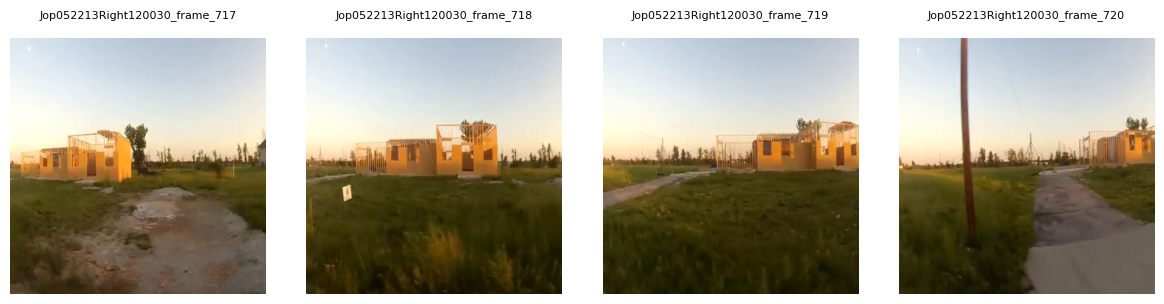

In [4]:
save_path = r"\...\original.png"

frame_paths = list_frames(address_folders)
image_titles = []
images = []

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

for frame_index, frame_path in enumerate(frame_paths):
    image = transform((Image.open(frame_path))).squeeze(0)
    image = image.permute(1, 2, 0)
    
    images.append(image)
    image_titles.append(f"{frame_path.stem}\n")

plot_gradcam(
    images,
    image_titles,
    save_path)

### Resnet50

In [5]:
checkpoint_path = r"\...\resnet50_epoch_021.pth"
save_path = r"\...\resnet50_gradcam.png"

Predicted class: Rebuilding
Predicted confidence: 0.9990


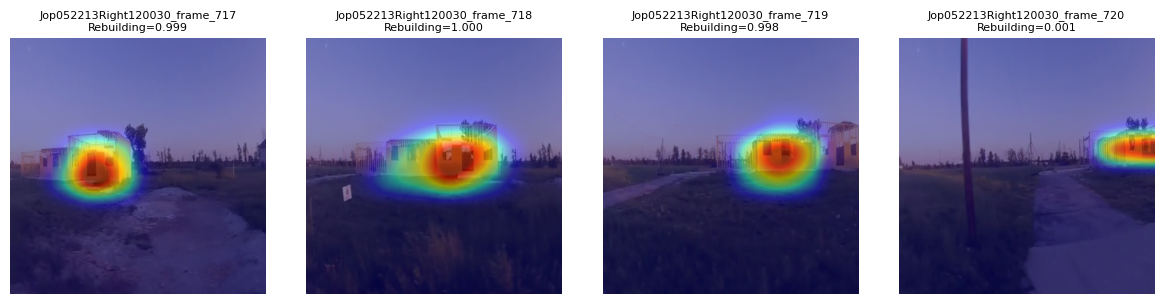

In [6]:
model, num_classes = load_resnet50(
    checkpoint_path=checkpoint_path,
    device="cpu"
)

gradcam_resnet50(
    model,
    address_folders=address_folders,
    class_names=class_names,
    save_path=save_path,
)

### CNN-LSTM

In [7]:
checkpoint_path = r"\...\cnn-lstm_epoch_017.pth"
save_path = r"\...\cnn_lstm_gradcam.png"

Predicted class: Rebuilding
Predicted confidence: 0.9982


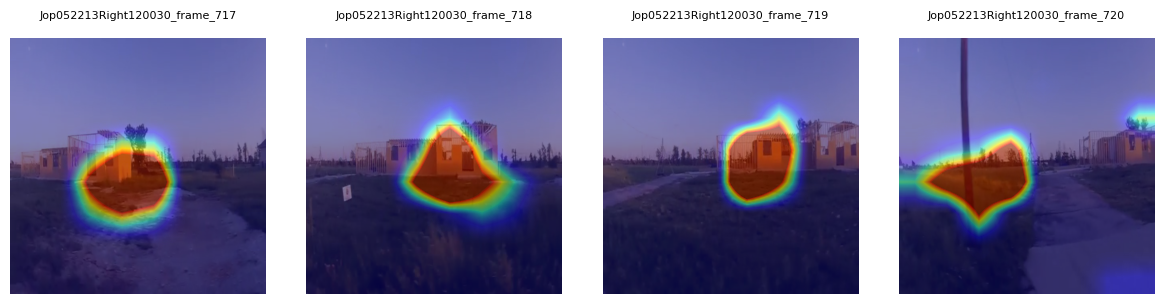

In [8]:
model = load_cnn_lstm(
    checkpoint_path=checkpoint_path,
    device="cpu",
    num_classes=len(class_names),
)

gradcam_hybrid(
    model,
    address_folders=address_folders,
    class_names=class_names,
    save_path=save_path,
)

### CNN-STM

In [9]:
checkpoint_path = r"\...\cnn-stm_epoch_027.pth"
save_path = r"\...\cnn_stm_gradcam.png"

Predicted class: Rebuilding
Predicted confidence: 1.0000


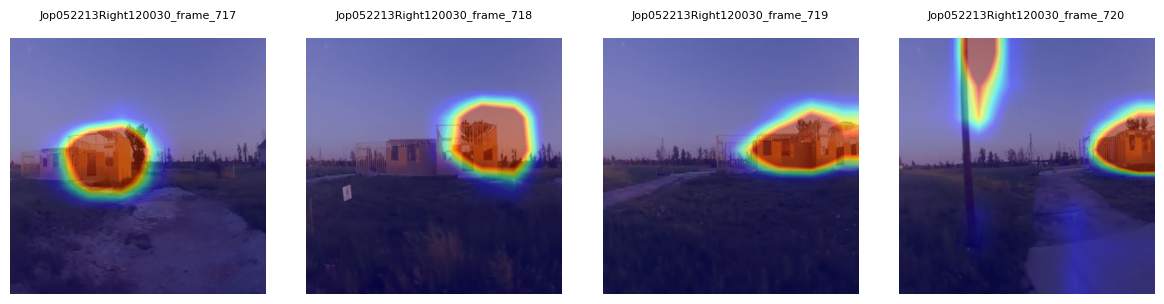

In [10]:
model = load_cnn_stm(
    checkpoint_path=checkpoint_path,
    device="cpu",
    num_classes=len(class_names),
)

gradcam_hybrid(
    model,
    address_folders=address_folders,
    class_names=class_names,
    save_path=save_path,
)

## SwinV2-Base

In [11]:
checkpoint_path = r"\...\swinv2_epoch_018.pth"
save_path = r"\...\swinv2_gradcam.png"

Predicted class: Rebuilding
Predicted confidence: 1.0000


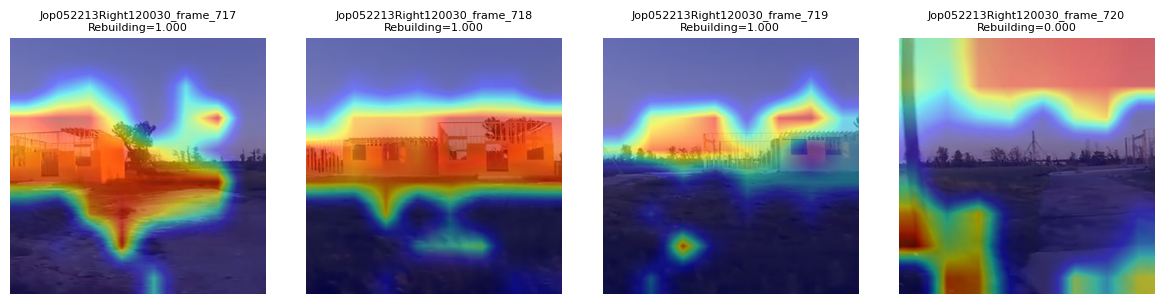

In [12]:
model = load_swinv2(
    checkpoint_path=checkpoint_path,
    device="cpu",
    num_classes=len(class_names),
)

gradcam_swin(
    model,
    address_folders=address_folders,
    class_names=class_names,
    save_path=save_path,
)